Training...
Iter 0: Loss = 1.9401e+00
Iter 1000: Loss = 3.8341e-02
Iter 2000: Loss = 2.2644e-02
Iter 3000: Loss = 5.9792e-03
Iter 4000: Loss = 3.1257e-03
Iter 5000: Loss = 1.7964e-03


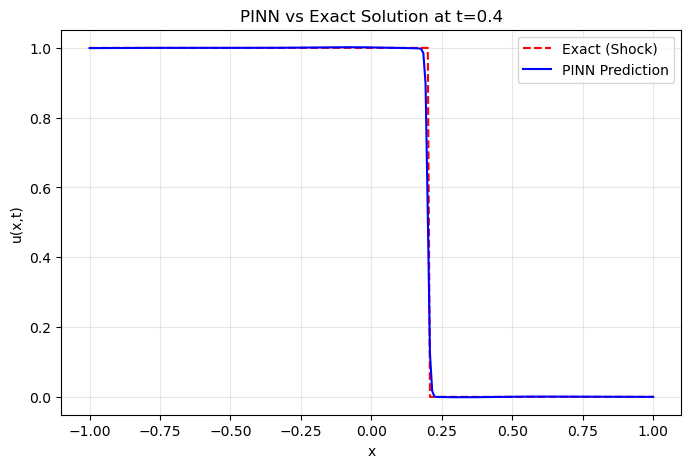

In [4]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from pyDOE import lhs

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. Physics & Exact Solution
# ==========================================
def exact_solution(x, t):
    """
    Analytical solution for the Riemann problem: u_t + u*u_x = 0.
    With IC: u(x,0) = 1 if x < 0 else 0.
    The shock moves at speed s = (1+0)/2 = 0.5.
    """
    shock_pos = 0.5 * t
    return np.where(x < shock_pos, 1.0, 0.0)

# ==========================================
# 2. Model Architectures
# ==========================================
class ViscosityNN(nn.Module):
    """Network to predict adaptive viscosity ν."""
    def __init__(self, layers, lb, ub):
        super().__init__()
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)
        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)
        
        fcn = []
        for i in range(len(layers) - 2):
            fcn.extend([nn.Linear(layers[i], layers[i+1]), nn.Tanh()])
        fcn.extend([nn.Linear(layers[-2], layers[-1]), nn.Softplus()]) # nu > 0
        self.model = nn.Sequential(*fcn)

    def forward(self, x):
        x_norm = 2.0 * (x - self.lb) / (self.ub - self.lb) - 1.0
        return self.model(x_norm)

class AdaptivePINN(nn.Module):
    """Physics-Informed Neural Network with Adaptive Viscosity and BC constraints."""
    def __init__(self, u_layers, vis_layers, lb, ub):
        super().__init__()
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)
        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)

        # Velocity Network u(x, t)
        u_fcn = []
        for i in range(len(u_layers) - 2):
            u_fcn.extend([nn.Linear(u_layers[i], u_layers[i+1]), nn.Tanh()])
        u_fcn.append(nn.Linear(u_layers[-2], u_layers[-1]))
        self.u_net = nn.Sequential(*u_fcn)

        # Viscosity Network ν(x, t)
        self.vis_net = ViscosityNN(vis_layers, lb, ub)

    def forward(self, x):
        x_norm = 2.0 * (x - self.lb) / (self.ub - self.lb) - 1.0
        return self.u_net(x_norm)

    def get_loss(self, x_ic, u_ic, x_bc, u_bc, x_f):
        """
        Calculates composite loss:
        Loss = IC_loss + BC_loss + PDE_residual + Viscosity_regularization
        """
        mse = nn.MSELoss()

        # 1. IC Loss: u(x, 0)
        loss_ic = mse(self.forward(x_ic), u_ic)

        # 2. BC Loss: u(-1, t) = 1 and u(1, t) = 0
        loss_bc = mse(self.forward(x_bc), u_bc)

        # 3. PDE Residual: u_t + u*u_x - ν^2 * u_xx = 0
        x_f.requires_grad_(True)
        u = self.forward(x_f)
        grads = autograd.grad(u, x_f, torch.ones_like(u), create_graph=True)[0]
        u_x, u_t = grads[:, 0:1], grads[:, 1:2]
        u_xx = autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        
        nu = self.vis_net(x_f)
        f_residual = u_t + u * u_x - (nu**2) * u_xx
        loss_f = mse(f_residual, torch.zeros_like(f_residual))

        # 4. Viscosity Loss: Encourages nu**2 --> 0
        # This forces the PINN to find the sharpest solution possible 
        # while nu acts as a learnable diffusion for stability.
        loss_v = torch.mean(nu**2)

        return loss_ic + loss_bc + loss_f + 1 * loss_v

# ==========================================
# 3. Data Prep & Training
# ==========================================
lb, ub = np.array([-1.0, 0.0]), np.array([1.0, 0.5])

# Initial Conditions (t=0)
x_ic = np.linspace(-1, 1, 200)[:, None]
X_ic = torch.tensor(np.hstack([x_ic, np.zeros_like(x_ic)]), dtype=torch.float32).to(device)
U_ic = torch.tensor(np.where(x_ic < 0, 1.0, 0.0), dtype=torch.float32).to(device)

# Boundary Conditions (x=-1, x=1)
t_bc = np.linspace(0, 0.5, 100)[:, None]
X_bc = torch.tensor(np.vstack([np.hstack([-1*np.ones_like(t_bc), t_bc]), 
                                np.hstack([np.ones_like(t_bc), t_bc])]), dtype=torch.float32).to(device)
U_bc = torch.tensor(np.vstack([np.ones_like(t_bc), np.zeros_like(t_bc)]), dtype=torch.float32).to(device)

# Collocation Points (PDE)
X_f = torch.tensor(lb + (ub - lb) * lhs(2, 10000), dtype=torch.float32).to(device)

model = AdaptivePINN([2, 20, 20, 20, 1], [2, 20, 1], lb, ub).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Training...")
for i in range(5001):
    optimizer.zero_grad()
    loss = model.get_loss(X_ic, U_ic, X_bc, U_bc, X_f)
    loss.backward()
    optimizer.step()
    if i % 1000 == 0:
        print(f"Iter {i}: Loss = {loss.item():.4e}")

# ==========================================
# 4. Visualization & Comparison
# ==========================================
t_test = 0.4
x_test = np.linspace(-1, 1, 256)[:, None]
X_test = torch.tensor(np.hstack([x_test, np.ones_like(x_test)*t_test]), dtype=torch.float32).to(device)

u_pred = model(X_test).cpu().detach().numpy()
u_true = exact_solution(x_test, t_test)

plt.figure(figsize=(8, 5))
plt.plot(x_test, u_true, 'r--', label='Exact (Shock)')
plt.plot(x_test, u_pred, 'b-', label='PINN Prediction')
plt.title(f"PINN vs Exact Solution at t={t_test}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()